In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))  # adds /home/patroklos/delphi.ai to the path

import torch as ch
from torch import sigmoid as sig
from torch.distributions import MultivariateNormal
import matplotlib.pyplot as plt
%matplotlib notebook
import numpy as np

from delphi.utils.helpers import logistic
from torch.distributions.gumbel import Gumbel
from delphi.grad import TruncatedBCE

In [2]:
gumbel = Gumbel(0, 1)

In [66]:
class TruncatedCE(ch.autograd.Function):
    @staticmethod
    def forward(ctx, pred, targ, phi, num_samples=5000, eps=1e-5):
        """
        Args: 
            pred (torch.Tensor): size (batch_size, 1) matrix for regression model predictions
            targ (torch.Tensor): size (batch_size, 1) matrix for regression target predictions
            phi (oracle.oracle): dependent variable membership oracle
            num_samples (int): number of samples to generate per sample in batch in rejection sampling procedure
            eps (float): denominator error constant to avoid divide by zero errors
        """        
        stacked = pred[None, ...].repeat(num_samples, 1, 1)
        rand_noise = gumbel.sample(stacked.size())
        # add noise
        noised = stacked + rand_noise
        noised_labs = noised.argmax(-1)
        # filter
        filtered = phi(noised)
        mask = (noised_labs).eq(targ)[...,None]
        filtered = filtered.float()
        ctx.save_for_backward(mask, filtered, rand_noise)
        ctx.eps = eps
        prob_est = (mask * filtered + eps).sum(0) / (filtered.sum(0) + eps)
        return -ch.log(prob_est) / pred.size(0)
        
    @staticmethod
    def backward(ctx, grad_output):  
        mask, filtered, rand_noise = ctx.saved_tensors
        inner_exp = (1 - ch.exp(-rand_noise))
        nll = ((inner_exp * mask * filtered).sum(0) / ((mask * filtered).sum(0) + ctx.eps))
        const = ((inner_exp * filtered).sum(0) / (filtered.sum(0) + ctx.eps))
        return (-nll + const) / pred.size(0), None, None, None, None

In [67]:
class TruncatedBCE(ch.autograd.Function):
    """
    Truncated binary cross entropy gradient for truncated binary classification tasks. 
    """
    @staticmethod
    def forward(ctx, pred, targ, phi, num_samples=1000, eps=1e-5):
        """
        Args: 
            pred (torch.Tensor): size (batch_size, 1) matrix for regression model predictions
            targ (torch.Tensor): size (batch_size, 1) matrix for regression target predictions
            phi (oracle.oracle): dependent variable membership oracle
            num_samples (int): number of samples to generate per sample in batch in rejection sampling procedure
            eps (float): denominator error constant to avoid divide by zero errors
        """  
        stacked = pred[None, ...].repeat(num_samples, 1, 1)
        rand_noise = logistic.sample(stacked.size())
        # add noise
        noised = stacked + rand_noise
        noised_labs = noised >= 0
        # filter
        filtered = phi(noised)
        mask = (noised_labs).eq(targ)
        filtered = filtered.float()
        ctx.save_for_backward(mask, filtered, rand_noise)
        ctx.eps = eps
        prob_est = (mask * filtered + eps).sum(0) / (filtered.sum(0) + ctx.eps)
        return -ch.log(prob_est) / pred.size(0)

    @staticmethod
    def backward(ctx, grad_output):
        mask, filtered, rand_noise = ctx.saved_tensors

        avg = 2*(sig(rand_noise) * mask * filtered).sum(0) / ((mask * filtered).sum(0) + ctx.eps) 
        norm_const = (2 * sig(rand_noise) * filtered).sum(0) / (filtered.sum(0) + ctx.eps)
        return -(avg - norm_const) / rand_noise.size(1), None, None, None, None

In [68]:
from torch.nn import CrossEntropyLoss

ce_loss = CrossEntropyLoss()

In [69]:
def trunc_logistic_mle(pred, targ, phi, seed=69): 
    if seed is not None:
        ch.manual_seed(seed)
    loss = TruncatedBCE.apply(pred, targ, phi)
    loss = loss.sum(0)
    loss.backward()
    return loss, pred.grad

def trunc_gumbel_mle(pred, targ, phi, seed=69): 
    if seed is not None:
        ch.manual_seed(seed)
    loss = TruncatedCE.apply(pred, targ, phi)
    loss = loss.sum(0)[...,None]
    loss.backward()
    return loss, pred.grad

# Untruncated Multinomial Logistic Regression

In [70]:
from sklearn.linear_model import LogisticRegression

D, K = 1, 2

W = ch.ones(K, D)

print(f'groud truth W:\n {W}')

G = Gumbel(0, 1)

NUM_SAMPLES = 5000
X = ch.rand(NUM_SAMPLES, D)
print(f'ground truth num samples: {X.size(0)}')

Z = X @ W.T + G.sample([NUM_SAMPLES, K])

Y = Z.argmax(-1)

log_reg = LogisticRegression(penalty=None, fit_intercept=False)
log_reg.fit(X, Y)

gt_w = ch.from_numpy(log_reg.coef_)

print(f'fitted w: {gt_w}')

groud truth W:
 tensor([[1.],
        [1.]])
ground truth num samples: 5000
fitted w: tensor([[0.0531]], dtype=torch.float64)


In [71]:
def phi(z): 
    z_diff = (z[...,0] - z[...,1])[...,None]
    return ch.ones_like(z_diff)

def phi_bce(z): 
    return ch.ones_like(z)

In [72]:
trunc_indices = phi(Z).flatten().nonzero().flatten()
X_trunc, Z_trunc = X[trunc_indices], Z[trunc_indices]
Y_trunc = Y[trunc_indices]
alpha = X_trunc.size(0) / X.size(0)
print(f'alpha: {alpha}')

trunc_log_reg = LogisticRegression(penalty=None,fit_intercept=False)
trunc_log_reg.fit(X_trunc, Y_trunc)

trunc_w = ch.from_numpy(trunc_log_reg.coef_)

print(f'trunc fitted w: {trunc_w}')

alpha: 1.0
trunc fitted w: tensor([[0.0531]], dtype=torch.float64)


<IPython.core.display.Javascript object>


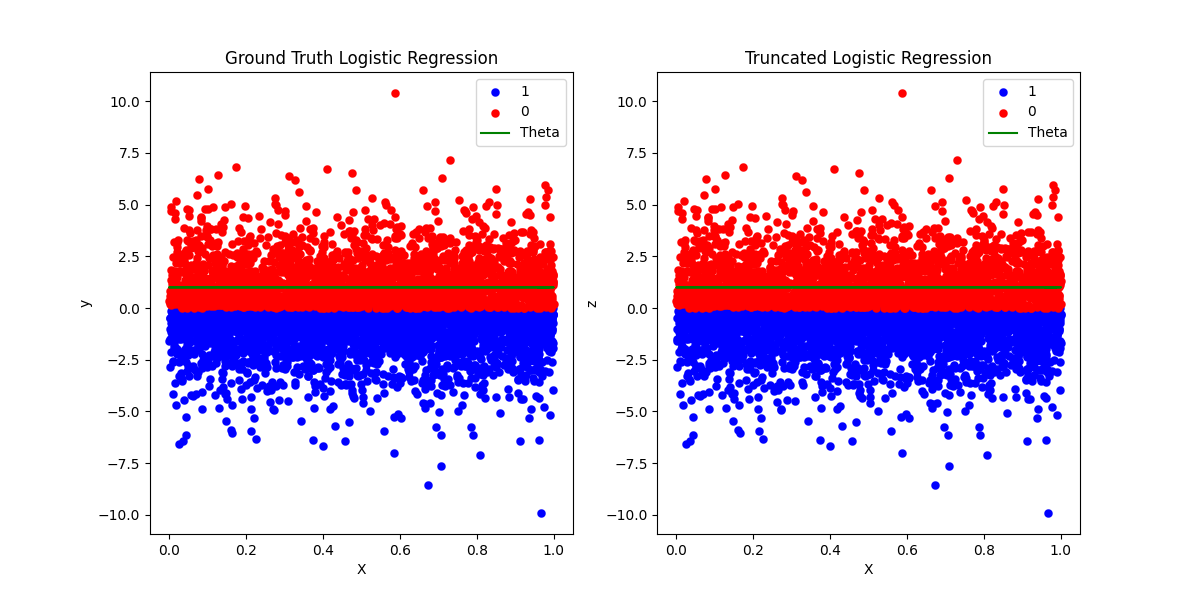

In [73]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ones = Y.flatten().nonzero().flatten()
zeros = (~Y.bool().flatten()).nonzero().flatten()

Z_zeros = Z[zeros]
Z_ones = Z[ones]

Z_zero_diff = Z_zeros[:,0] - Z_zeros[:,1]
Z_one_diff = Z_ones[:,0] - Z_ones[:,1]

ax1.scatter(X[ones], Z_one_diff, linewidths=.1, color='blue', label='1')
ax1.scatter(X[zeros], Z_zero_diff, linewidths=.1, color='red', label='0')
X_sorted = X.sort()[0]
pred = log_reg.predict(X_sorted)
ax1.plot(X_sorted, pred, color='green', label='Theta')
ax1.set_xlabel('X')
ax1.set_ylabel('y')
ax1.set_title('Ground Truth Logistic Regression')
ax1.legend()

trunc_ones = Y_trunc.flatten().nonzero().flatten()
trunc_zeros = (~Y_trunc.bool().flatten()).nonzero().flatten()

Z_trunc_ones = Z_trunc[trunc_ones]
Z_trunc_zeros = Z_trunc[trunc_zeros]

Z_trunc_zero_diff = Z_trunc_zeros[:,0] - Z_trunc_zeros[:,1]
Z_trunc_one_diff = Z_trunc_ones[:,0] - Z_trunc_ones[:,1] 

ax2.scatter(X_trunc[trunc_ones], Z_trunc_one_diff, linewidths=.1, color='blue', label='1')
ax2.scatter(X_trunc[trunc_zeros], Z_trunc_zero_diff, linewidths=.1, color='red', label='0')
trunc_pred = trunc_log_reg.predict(X_sorted)
ax2.plot(X_sorted, trunc_pred, color='green', label='Theta')
ax2.set_xlabel('X')
ax2.set_ylabel('z')
ax2.set_title('Truncated Logistic Regression')
ax2.legend()
plt.show()

In [74]:
from torch.nn import BCEWithLogitsLoss

In [75]:
bce = BCEWithLogitsLoss()


ws = ch.linspace(-3, 5, 10)

losses = ch.Tensor([])
grads = ch.Tensor([])

trunc_bce_losses = ch.Tensor([])
trunc_bce_grads = ch.Tensor([])

bce_losses = ch.Tensor([])
bce_grads = ch.Tensor([])

ce_losses = ch.Tensor([])
ce_grads = ch.Tensor([])

for w in ws: 
    for w_ in ws:
        W_ = ch.cat([w[...,None], w_[...,None]])[None,...]
        pred = X_trunc@W_
        pred.requires_grad = True
        loss_bce = bce(pred[:,1] - pred[:,0], Y_trunc.float())
        loss_bce.backward()
        bce_losses = ch.cat([bce_losses, loss_bce[...,None].detach()])
        bce_grads = ch.cat([bce_grads, X_trunc.T@pred.grad])
        
        pred = X_trunc@W_
        pred.requires_grad = True
        loss_trunc_bce, pred_grad = trunc_logistic_mle((pred[:,1] - pred[:,0])[...,None], Y_trunc.float()[...,None], phi_bce)
        trunc_bce_losses = ch.cat([trunc_bce_losses, loss_trunc_bce[...,None].detach()])
        trunc_bce_grads = ch.cat([trunc_bce_grads, X_trunc.T@pred.grad])
        
        pred = X_trunc@W_
        pred.requires_grad = True
        loss_ce = ce_loss(pred, Y_trunc.long())
        loss_ce.backward()
        ce_losses = ch.cat([ce_losses, loss_ce[...,None].detach()])
        ce_grads = ch.cat([ce_grads, X_trunc.T@pred.grad])
        
        
        pred = X_trunc@W_
        pred.requires_grad = True
        loss, pred_grad = trunc_gumbel_mle(pred, Y_trunc, phi)
        losses = ch.cat([losses, loss[...,None].detach()])
        grads = ch.cat([grads, X_trunc.T@pred_grad])

/tmp/ipykernel_66853/1911581757.py:9: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:489.)
  return loss, pred.grad


In [76]:
losses = losses.flatten()

<IPython.core.display.Javascript object>


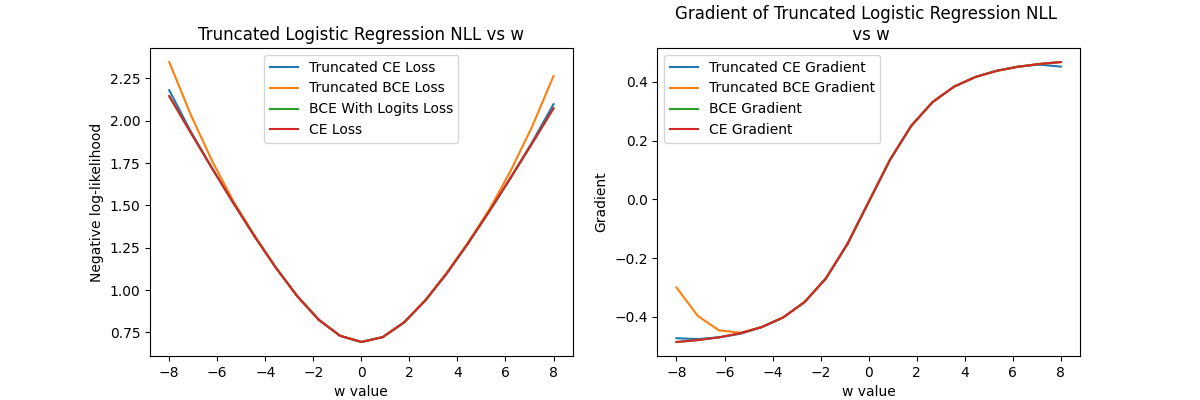

In [77]:
WS_ = ch.Tensor([])

for w_ in ws: 
    for w__ in ws: 
        WS_ = ch.cat([WS_, ch.cat([w_[...,None], w__[...,None]])[None,...]])

w_diffs = WS_[:,1] - WS_[:,0]

w_sorted, indices = w_diffs.sort()

# === Plot the loss landscape ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(w_sorted, losses[indices], label="Truncated CE Loss")
ax1.plot(w_sorted, trunc_bce_losses[indices], label="Truncated BCE Loss")
ax1.plot(w_sorted, bce_losses[indices], label="BCE With Logits Loss")
ax1.plot(w_sorted, ce_losses[indices], label="CE Loss")

ax1.set_xlabel("w value")
ax1.set_ylabel("Negative log-likelihood")
ax1.set_title("Truncated Logistic Regression NLL vs w")
ax1.legend()

ax2.plot(w_sorted, grads[:,1][indices] - grads[:,0][indices], label="Truncated CE Gradient")
ax2.plot(w_sorted, trunc_bce_grads[:,1][indices] - trunc_bce_grads[:,0][indices], label="Truncated BCE Gradient")
ax2.plot(w_sorted, bce_grads[:,1][indices] - bce_grads[:,0][indices], label="BCE Gradient")
ax2.plot(w_sorted, ce_grads[:,1][indices] - ce_grads[:,0][indices], label="CE Gradient")


ax2.set_xlabel("w value")
ax2.set_ylabel("Gradient")
ax2.set_title("Gradient of Truncated Logistic Regression NLL \n vs w")
ax2.legend()

plt.show()

#  Truncated Multinomial Logistic Regression

In [78]:
from sklearn.linear_model import LogisticRegression

D, K = 1, 2

W = ch.ones(K, D)

print(f'groud truth W:\n {W}')

G = Gumbel(0, 1)

NUM_SAMPLES = 5000
X = ch.rand(NUM_SAMPLES, D)
print(f'ground truth num samples: {X.size(0)}')

Z = X @ W.T + G.sample([NUM_SAMPLES, K])

Y = Z.argmax(-1)

log_reg = LogisticRegression(penalty=None, fit_intercept=False)
log_reg.fit(X, Y)

gt_w = ch.from_numpy(log_reg.coef_)

print(f'fitted w: {gt_w}')

groud truth W:
 tensor([[1.],
        [1.]])
ground truth num samples: 5000
fitted w: tensor([[0.0191]], dtype=torch.float64)


In [79]:
def phi(z): 
    z_diff = (z[...,1] - z[...,0])[...,None]
    return z_diff > -.25

def phi_bce(z): 
    return z > -.25

In [80]:
trunc_indices = phi(Z).flatten().nonzero().flatten()
X_trunc, Z_trunc = X[trunc_indices], Z[trunc_indices]
Y_trunc = Y[trunc_indices]
alpha = X_trunc.size(0) / X.size(0)
print(f'alpha: {alpha}')

trunc_log_reg = LogisticRegression(penalty=None,fit_intercept=False)
trunc_log_reg.fit(X_trunc, Y_trunc)

trunc_w = ch.from_numpy(trunc_log_reg.coef_)

print(f'trunc fitted w: {trunc_w}')

alpha: 0.5608
trunc fitted w: tensor([[3.4588]], dtype=torch.float64)


<IPython.core.display.Javascript object>


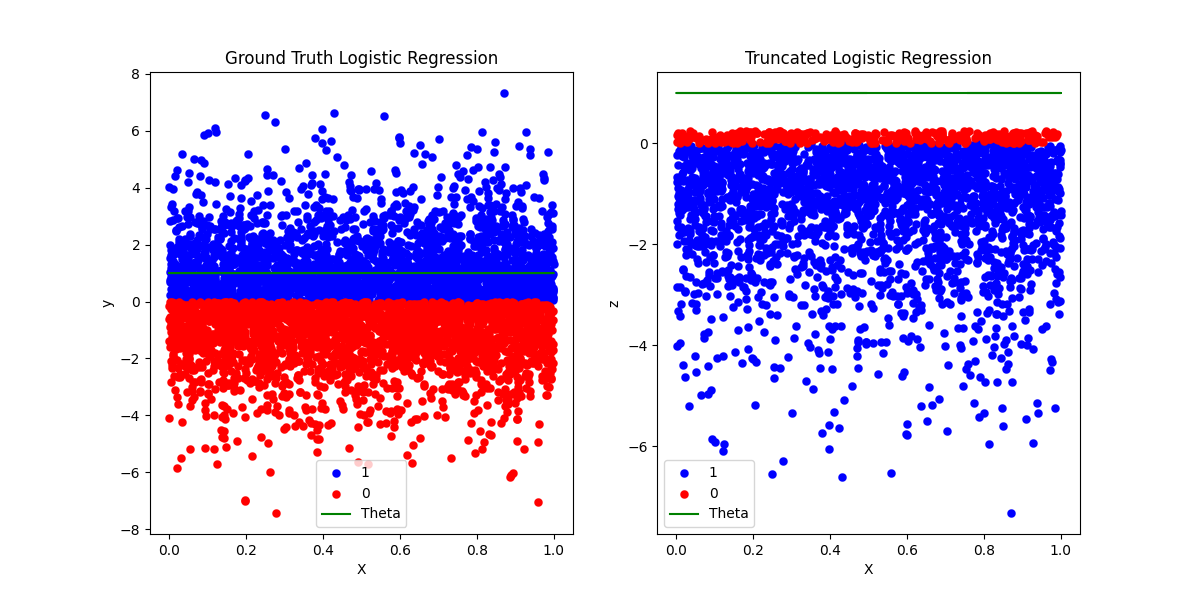

In [81]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ones = Y.flatten().nonzero().flatten()
zeros = (~Y.bool().flatten()).nonzero().flatten()

Z_zeros = Z[zeros]
Z_ones = Z[ones]

Z_zero_diff = Z_zeros[:,1] - Z_zeros[:,0]
Z_one_diff = Z_ones[:,1] - Z_ones[:,0]

ax1.scatter(X[ones], Z_one_diff, linewidths=.1, color='blue', label='1')
ax1.scatter(X[zeros], Z_zero_diff, linewidths=.1, color='red', label='0')
X_sorted = X.sort()[0]
pred = log_reg.predict(X_sorted)
ax1.plot(X_sorted, pred, color='green', label='Theta')
ax1.set_xlabel('X')
ax1.set_ylabel('y')
ax1.set_title('Ground Truth Logistic Regression')
ax1.legend()

trunc_ones = Y_trunc.flatten().nonzero().flatten()
trunc_zeros = (~Y_trunc.bool().flatten()).nonzero().flatten()

Z_trunc_ones = Z_trunc[trunc_ones]
Z_trunc_zeros = Z_trunc[trunc_zeros]

Z_trunc_zero_diff = Z_trunc_zeros[:,0] - Z_trunc_zeros[:,1]
Z_trunc_one_diff = Z_trunc_ones[:,0] - Z_trunc_ones[:,1] 

ax2.scatter(X_trunc[trunc_ones], Z_trunc_one_diff, linewidths=.1, color='blue', label='1')
ax2.scatter(X_trunc[trunc_zeros], Z_trunc_zero_diff, linewidths=.1, color='red', label='0')
trunc_pred = trunc_log_reg.predict(X_sorted)
ax2.plot(X_sorted, trunc_pred, color='green', label='Theta')
ax2.set_xlabel('X')
ax2.set_ylabel('z')
ax2.set_title('Truncated Logistic Regression')
ax2.legend()
plt.show()

In [ ]:
bce = BCEWithLogitsLoss()

ws = ch.linspace(-3, 5, 10)

losses = ch.Tensor([])
grads = ch.Tensor([])

trunc_bce_losses = ch.Tensor([])
trunc_bce_grads = ch.Tensor([])

bce_losses = ch.Tensor([])
bce_grads = ch.Tensor([])

ce_losses = ch.Tensor([])
ce_grads = ch.Tensor([])

for w in ws: 
    for w_ in ws:
        W_ = ch.cat([w[...,None], w_[...,None]])[None,...]
        pred = X_trunc@W_
        pred.requires_grad = True
        loss_bce = bce(pred[:,1] - pred[:,0], Y_trunc.float())
        loss_bce.backward()
        bce_losses = ch.cat([bce_losses, loss_bce[...,None].detach()])
        bce_grads = ch.cat([bce_grads, X_trunc.T@pred.grad])
        
        pred = X_trunc@W_
        pred.requires_grad = True
        loss_trunc_bce, pred_grad = trunc_logistic_mle((pred[:,1] - pred[:,0])[...,None], Y_trunc.float()[...,None], phi_bce)
        trunc_bce_losses = ch.cat([trunc_bce_losses, loss_trunc_bce[...,None].detach()])
        trunc_bce_grads = ch.cat([trunc_bce_grads, X_trunc.T@pred.grad])
        
        pred = X_trunc@W_
        pred.requires_grad = True
        loss_ce = ce_loss(pred, Y_trunc.long())
        loss_ce.backward()
        ce_losses = ch.cat([ce_losses, loss_ce[...,None].detach()])
        ce_grads = ch.cat([ce_grads, X_trunc.T@pred.grad])
        
        
        pred = X_trunc@W_
        pred.requires_grad = True
        loss, pred_grad = trunc_gumbel_mle(pred, Y_trunc, phi)
        losses = ch.cat([losses, loss[...,None].detach()])
        grads = ch.cat([grads, X_trunc.T@pred_grad])

/tmp/ipykernel_66853/1911581757.py:9: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:489.)
  return loss, pred.grad


In [64]:
losses = losses.flatten()

<IPython.core.display.Javascript object>


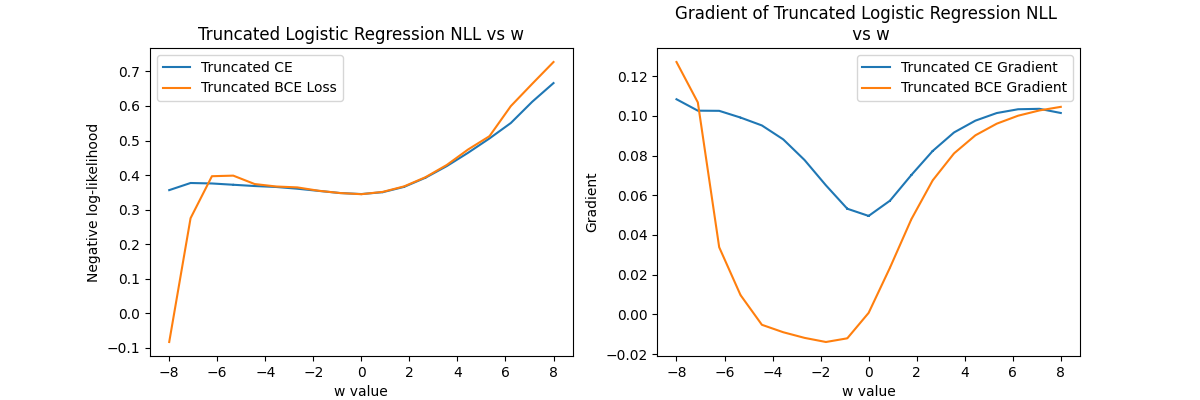

In [65]:
WS_ = ch.Tensor([])

for w_ in ws: 
    for w__ in ws: 
        WS_ = ch.cat([WS_, ch.cat([w_[...,None], w__[...,None]])[None,...]])

w_diffs = WS_[:,1] - WS_[:,0]

w_sorted, indices = w_diffs.sort()

# === Plot the loss landscape ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(w_sorted, losses[indices], label="Truncated CE")
ax1.plot(w_sorted, trunc_bce_losses[indices], label="Truncated BCE Loss")
# ax1.plot(w_sorted, bce_losses[indices], label="BCE With Logits Loss")
# ax1.plot(w_sorted, ce_losses[indices], label="CE")

ax1.set_xlabel("w value")
ax1.set_ylabel("Negative log-likelihood")
ax1.set_title("Truncated Logistic Regression NLL vs w")
ax1.legend()

ax2.plot(w_sorted, grads[:,1][indices] - grads[:,0][indices], label="Truncated CE Gradient")
ax2.plot(w_sorted, trunc_bce_grads[:,1][indices] - trunc_bce_grads[:,0][indices], label="Truncated BCE Gradient")
# ax2.plot(w_sorted, bce_grads[:,1][indices] - bce_grads[:,0][indices], label="BCE Gradient")
# ax2.plot(w_sorted, ce_grads[:,1][indices] - ce_grads[:,0][indices], label="CE Gradient")


ax2.set_xlabel("w value")
ax2.set_ylabel("Gradient")
ax2.set_title("Gradient of Truncated Logistic Regression NLL \n vs w")
ax2.legend()

plt.show()

In [33]:
w_diffs[losses[(w_diffs <= 4).nonzero().flatten()].argmin()]

tensor(-1.7778)

In [42]:
trunc_bce_losses.argmin()

tensor(90)

In [40]:
indices_ = ((WS_[:,1] - WS_[:,0]) > -4).nonzero().flatten()

In [49]:
WS_[indices_][trunc_bce_losses[indices_].argmin()]

tensor([-3., -3.])

In [46]:
WS_[90, 1] - WS_[90, 0]

tensor(-8.)

In [48]:
WS_[indices][0, 1] - WS_[indices][0, 0]

tensor(-8.)